# BHNS GRB Classification

Classifying Black Hole Neutron Star mergers from the COMPAS fiducial population (Model A, Broekgaarden et al. [2021, Paper I](https://arxiv.org/abs/2103.02608); [2022, Paper II](https://arxiv.org/abs/2112.05763)) using the [Gottlieb et al. (2023)](https://arxiv.org/abs/2309.00038) scheme with the [Foucart et al. (2018)](https://arxiv.org/abs/1807.00011) NS tidal disruption formula.

**Classification rules (BHNS):**
- NS not disrupted outside ISCO, or disk mass `M_d < 0.01 M☉` → No GRB (sub-threshold for jet launching)
- Disrupted, disk mass `0.01 ≤ M_d < 0.1 M☉` → Short cbGRB
- Disrupted, disk mass `M_d ≥ 0.1 M☉` → Long cbGRB

**Threshold note:** The 0.01 and 0.1 $M_\odot$ disk mass boundaries are approximate values from GRMHD simulations, not sharp physical thresholds. They carry systematic uncertainty of factors of a few, particularly the 0.01 $M_\odot$ lower limit for jet launching, which depends on magnetic field geometry and neutrino cooling.

The "Long cbGRB" category corresponds to merger-driven long GRBs, whose kilonovae show elevated red ejecta masses indicative of large tidal dynamical ejecta from asymmetric compact binaries ([Rastinejad et al. 2025](https://doi.org/10.3847/1538-4357/ad9c77)).

BH spin `a` is not tracked by COMPAS; results are shown for `a = 0.0, 0.3, 0.5, 0.7, 0.9`.

**Mass-ratio convention:** $Q = M_{\rm BH}/M_{\rm NS}$, consistent with the Foucart et al. (2018) parameterisation and Gottlieb et al. (2023) Figure 2.

**Data:** COMPAS fiducial BHNS simulation (Model A of Broekgaarden et al. 2021, Paper I) from [Zenodo 5178777](https://zenodo.org/records/5178777)

## 1. Load Data

Loading the COMPAS fiducial (Model A) BHNS population from Broekgaarden et al. (2021), which simulates $\sim 10^6$ binary systems across 53 metallicities using the STROOPWAFEL adaptive sampling algorithm. M1 and M2 are reassigned using `stellarType` flags to ensure M_BH is always the black hole and M_NS is always the neutron star, regardless of which was the primary.

In [1]:
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt

path  = '/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BHNS_A.h5'
fdata = h5.File(path, 'r')
fDCO  = fdata['doubleCompactObjects']

M_BH           = fDCO['M1'][...].squeeze()
M_NS           = fDCO['M2'][...].squeeze()
weights        = fDCO['weight'][...].squeeze()
metallicity    = fDCO['Metallicity1'][...].squeeze()
mergesInHubble = fDCO['mergesInHubbleTimeFlag'][...].squeeze()
tc             = fDCO['tc'][...].squeeze()
tform          = fDCO['tform'][...].squeeze()
m1zams         = fDCO['M1ZAMS'][...].squeeze()
m2zams         = fDCO['M2ZAMS'][...].squeeze()
stype1         = fDCO['stellarType1'][...].squeeze()
stype2         = fDCO['stellarType2'][...].squeeze()

is_BH1 = (stype1 == 14)
M1_orig = M_BH.copy()
M2_orig = M_NS.copy()
M_BH    = np.where(is_BH1, M1_orig, M2_orig)
M_NS    = np.where(is_BH1, M2_orig, M1_orig)

mask_merging = (mergesInHubble == 1)
print(f"Total BHNS:             {len(M_BH):,}")
print(f"Merging in Hubble time: {mask_merging.sum():,}")
print(f"BH mass range: {M_BH[mask_merging].min():.1f} - {M_BH[mask_merging].max():.1f} M☉")
print(f"NS mass range: {M_NS[mask_merging].min():.2f} - {M_NS[mask_merging].max():.2f} M☉")

Total BHNS:             1,525,553
Merging in Hubble time: 1,525,553
BH mass range: 2.7 - 39.2 M☉
NS mass range: 1.26 - 2.50 M☉


## 2. Foucart Disk Mass

Implementation of Foucart et al. (2018) Eq. (4) & (6) [arXiv:1807.00011]:

1. **No Eggleton pre-check:** The fitting-formula bracket naturally returns zero when the NS plunges without disruption, so the Eggleton (1983) Roche lobe approximation is unnecessary here and has been removed. (The Eggleton formula assumes Newtonian gravity and equilibrium mass transfer, neither of which applies at merger; the Foucart formula's $\max(0,\ldots)$ bracket is the sufficient disruption criterion.)
2. **Correct parameterisation:** Uses $\hat{R}_{\rm ISCO} = R_{\rm ISCO}/M_{\rm BH}$ (dimensionless, Eq. 3), the symmetric mass ratio $\eta$, and the full $\delta = 1.761$ exponent from Eq. (6).
3. **Baryon mass correction:** The Foucart formula predicts $\hat{M}_{\rm rem} = M_{\rm rem}/M^b_{\rm NS}$, where $M^b_{\rm NS}$ is the *baryon* (not gravitational) mass. We convert gravitational to baryon mass using $M^b \approx M_g + 0.080\,M_g^2$ (Gao et al. 2020; Lattimer & Prakash 2001), the best-fit coefficient for non-rotating NS. This corrects a ~10 to 15% systematic underestimate in disk mass.
4. **Mass-dependent NS radius:** By default, the NS radius follows a simple quadratic model calibrated to moderate-stiffness EOS (APR4/SLy family), with $R_{1.4} = 12.0$ km consistent with NICER constraints (Miller+ 2021, Riley+ 2021). This avoids unphysical compactness values for $M_{\rm NS} \gg 1.4\,M_\odot$ that arise from a fixed radius assumption. For EOS sensitivity sweeps, a fixed `R_NS_km` can still be passed.
5. **Remnant-to-disk conversion (simplification):** The formula predicts total remnant baryon mass $M_{\rm rem}$, not disk mass directly (Foucart 2012, Sec. VI). The standard approach (Coughlin et al. 2020; PyCBC) computes $M_{\rm disk} = M_{\rm rem} - M_{\rm dyn}$, subtracting dynamical ejecta estimated from Kawaguchi et al. (2016) or Kruger & Foucart (2020). As a simplification, we instead apply a constant multiplicative fraction: $M_{\rm disk} = f_{\rm disk}\,M_{\rm rem}$ with $f_{\rm disk} = 0.4$, a midrange estimate consistent with NR simulations showing $\sim 1/3$ to $\sim 2/3$ of remnant material settling into a disk (Foucart 2012, Sec. VI). Sensitivity to $f_{\rm disk} = 1/3$ and $1/2$ is shown separately.

In [ ]:
from grb_physics import (r_isco, ns_baryon_mass, ns_radius,
                         foucart_disk_mass, F_DISK,
                         MDISK_SHORT, MDISK_LONG)

### Foucart et al. (2018) implementation

The `foucart_disk_mass` function implements Eq. (4) of Foucart, Hinderer & Nissanke (2018) [arXiv:1807.00011]:

$$\hat{M}_{\rm rem} = \left[\max\!\left(\alpha\frac{1-2C_{\rm NS}}{\eta^{1/3}} - \beta\frac{\hat{R}_{\rm ISCO}\,C_{\rm NS}}{\eta} + \gamma,\;0\right)\right]^\delta$$

with $(\alpha,\beta,\gamma,\delta) = (0.406, 0.139, 0.255, 1.761)$ from Eq. (6), $\hat{R}_{\rm ISCO} = R_{\rm ISCO}/M_{\rm BH}$ from Eq. (3), and $\eta = M_{\rm NS}M_{\rm BH}/(M_{\rm NS}+M_{\rm BH})^2$.

**Baryon mass correction:** The Foucart formula predicts $\hat{M}_{\rm rem} = M_{\rm rem}/M^b_{\rm NS}$, where $M^b_{\rm NS}$ is the baryon mass. We convert $M_{\rm NS}$ (gravitational) to baryon mass via $M^b \approx M_g + 0.080\,M_g^2$ (Gao et al. 2020; Lattimer & Prakash 2001), with A = 0.080 the best-fit for non-rotating NS. This corrects a ~10 to 15% underestimate in $M_{\rm rem}$ that arises from using gravitational mass directly.

**Mass-dependent radius:** By default, $R_{\rm NS}(M)$ follows a simple quadratic calibrated to moderate-stiffness EOS, with $R_{1.4} = 12.0$ km (NICER). A fixed `R_NS_km` can be passed for EOS sensitivity sweeps.

The output $M_{\rm rem}$ is the **total remnant baryon mass** (disk + tidal tail + ejecta), not the accretion disk mass alone (Foucart 2012, Sec. VI). The standard approach (Coughlin et al. 2020, MNRAS 492, 863; PyCBC) computes $M_{\rm disk} = M_{\rm rem} - M_{\rm dyn}$, subtracting dynamical ejecta estimated from fitting formulae (Kawaguchi et al. 2016; Kruger & Foucart 2020). As a simplification, we instead apply a constant fraction before classification:
$$M_{\rm disk} = f_{\rm disk}\,M_{\rm rem}, \quad f_{\rm disk} = 0.4$$

This midrange value is consistent with NR simulations showing $\sim 1/3$ to $\sim 2/3$ of remnant material settling into a disk (Foucart 2012, Sec. VI). Sensitivity to $f_{\rm disk} = 1/3$ and $1/2$ is shown in Section 14.

The Eggleton (1983) Roche lobe pre-check has been removed: it assumes Newtonian gravity and equilibrium mass transfer, which are not applicable in the strong-gravity regime relevant to compact mergers. The Foucart formula's $\max(0,\ldots)$ bracket is the correct and sufficient disruption criterion, naturally returning zero when the NS is not disrupted.

## 3. GRB Classification for Five BH Spin Values

### BH spin prior: key systematic

COMPAS does not output natal BH spins for this dataset. BH spin is the single most important parameter for BHNS disruption: it determines the ISCO radius and hence whether the NS is tidally disrupted before plunge.

**Fiducial choice:** $a = 0.5$ sits near the disruption boundary and is therefore maximally uncertain; small changes in spin dramatically shift the GRB-class fractions.

**Astrophysical context:**
- **Fuller & Ma (2019, ApJL 881, L1)** predict low natal spins ($a \sim 0.0$ to $0.1$) for BHs formed in isolated field binaries due to efficient angular momentum transport via the Tayler instability. (Note: a companion paper, Ma & Fuller 2019, MNRAS 488, 4338, addresses NS spins specifically.) Under this prior, virtually all BHNS mergers would plunge without disruption, eliminating the BHNS GRB channel entirely.
- **Tidal spin-up** during mass transfer can increase spins, but the magnitude depends on the binary evolution pathway and is not well constrained.
- The spin sensitivity plots below (at $a = 0.0$, $0.3$, $0.5$, $0.7$, $0.9$) bracket this systematic. The $a = 0.3$ node captures the steep disruption cliff between $a = 0$ and $a = 0.5$, improving quadrature accuracy. Results should always be quoted conditional on the assumed spin.

All GRB-class fractions below, including the "No GRB" (dark) fraction, are **conditional on the assumed spin value**. The No-GRB fraction is particularly spin-sensitive: at $a = 0.0$ nearly all systems fail to disrupt, while at $a = 0.9$ a substantial fraction produces an observable GRB.

**Spin-marginalized cosmic rates** using these priors (flat and Fuller & Ma 2019) are computed in `GRB_CosmicRate.ipynb`, Section 14. The marginalized rates show that under a low-spin prior, the BHNS Long cbGRB channel contributes negligibly to the total GRB rate.

**Population synthesis uncertainties:** Beyond spin, Broekgaarden et al. (2021) show that BHNS merger rates are sensitive to both stellar evolution assumptions (mass transfer, CE efficiency, SN kicks) and the metallicity-specific star formation history $\mathcal{S}(Z, z)$, with predicted rates varying by factors of $10^2$ to $10^4$ across their 560 model realizations. The results below use only their fiducial Model A; the full model spread should be kept in mind when interpreting absolute rates.

**Spin-orbit misalignment:** This analysis assumes aligned BH spins. For misaligned spins, the effective spin component along the orbital angular momentum determines the ISCO radius; retrograde tilts produce smaller effective spins and hence larger ISCOs, making disruption harder. This is discussed in the Foucart literature but not modeled here.

**Mass gap uncertainty:** COMPAS BH masses depend on the supernova prescription (rapid vs delayed from Fryer et al. 2012). The lower mass gap between ~2.5-5 $M_\odot$ is sensitive to this choice and affects which systems can produce GRBs, since lower-mass BHs are easier to disrupt.

In [3]:
BH  = M_BH[mask_merging]
NS  = M_NS[mask_merging]
w   = weights[mask_merging]

results = {}  # keyed by BH spin value
for a in [0.0, 0.3, 0.5, 0.7, 0.9]:
    M_disk    = foucart_disk_mass(BH, NS, a_BH=a)
    no_grb    = (M_disk < 0.01)
    short_grb = (M_disk >= 0.01) & (M_disk < 0.1)
    long_grb  = (M_disk >= 0.1)
    results[a] = (no_grb, short_grb, long_grb, M_disk)
    print(f"a={a}: No GRB={no_grb.sum():,} ({100*no_grb.mean():.1f}%)  "
          f"Short={short_grb.sum():,} ({100*short_grb.mean():.1f}%)  "
          f"Long={long_grb.sum():,} ({100*long_grb.mean():.1f}%)")

a=0.0: No GRB=1,525,196 (100.0%)  Short=357 (0.0%)  Long=0 (0.0%)
a=0.3: No GRB=1,512,304 (99.1%)  Short=13,249 (0.9%)  Long=0 (0.0%)
a=0.5: No GRB=1,472,673 (96.5%)  Short=52,880 (3.5%)  Long=0 (0.0%)
a=0.7: No GRB=1,303,405 (85.4%)  Short=222,074 (14.6%)  Long=74 (0.0%)


a=0.9: No GRB=865,876 (56.8%)  Short=528,108 (34.6%)  Long=131,569 (8.6%)


## 4. M_BH vs M_NS Mass Plane

Each panel shows the mass plane for a different assumed BH spin ($a = 0.0$, $0.3$, $0.5$, $0.7$, $0.9$). Systems are colored by GRB classification: orange = Long cbGRB ($M_{\rm disk} \geq 0.1\,M_\odot$), blue = Short cbGRB ($0.01 \leq M_{\rm disk} < 0.1\,M_\odot$), and gray = No GRB ($M_{\rm disk} < 0.01\,M_\odot$ or NS plunges). Contours mark the disruption threshold ($M_{\rm disk} = 0$) and the Long/Short boundary ($M_{\rm disk} = 0.1\,M_\odot$).

The Long cbGRB systems (orange) occupy the low $Q$, high-spin corner of parameter space where tidal disruption is most efficient. Observationally, kilonovae following merger-driven long GRBs show elevated tidal ejecta masses ($M_{\rm ej,R} \sim 0.05\,M_\odot$; Rastinejad et al. 2025), consistent with asymmetric binaries producing massive post-merger disks. The BHNS mass distributions predicted by this COMPAS Model A are broadly consistent with those in Broekgaarden et al. (2021, their Figures 8 and 9), with BH masses spanning $\sim$3 to 40 $M_\odot$ and NS masses concentrated near 1.3 $M_\odot$.

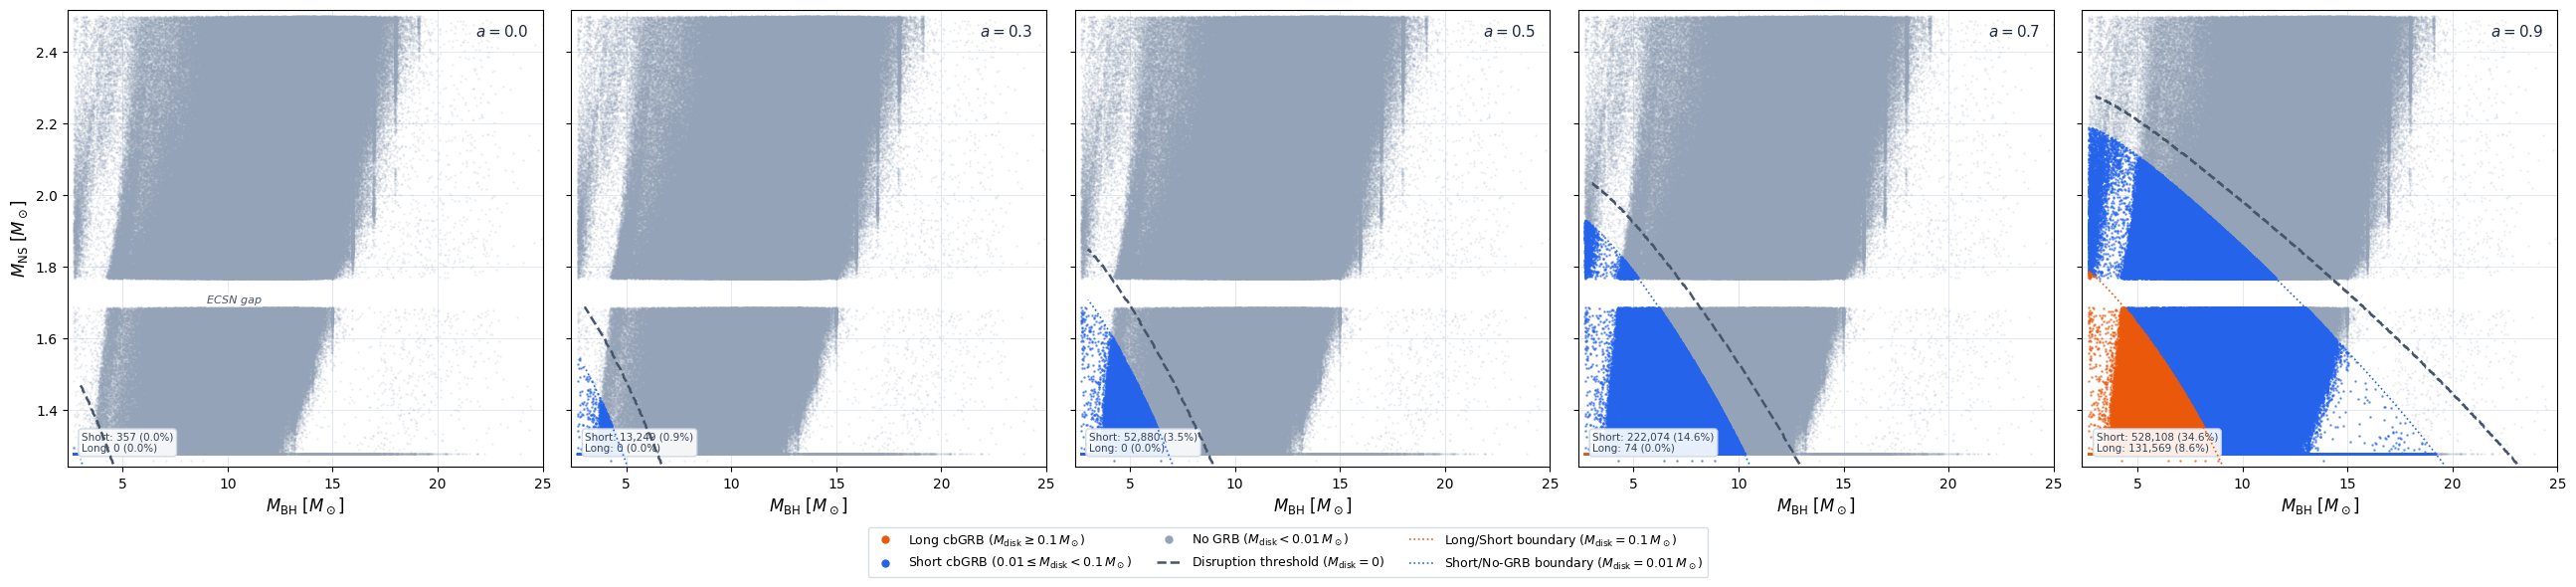

In [4]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 5, figsize=(26, 5.8), sharey=True, sharex=True)
spins = [0.0, 0.3, 0.5, 0.7, 0.9]

BH = M_BH[mask_merging]
NS = M_NS[mask_merging]

_mbh = np.linspace(3, 25, 500)
_mns = np.linspace(1.25, 2.5, 300)
_MBH, _MNS = np.meshgrid(_mbh, _mns)

for ax, a in zip(axes, spins):
    no_grb, short_grb, long_grb, M_disk_arr = results[a]

    ax.scatter(BH[no_grb],    NS[no_grb],    s=0.3, alpha=0.20, color='#94A3B8', rasterized=True, zorder=1)
    ax.scatter(BH[short_grb], NS[short_grb], s=0.8, alpha=0.55, color='#2563EB', rasterized=True, zorder=2)
    ax.scatter(BH[long_grb],  NS[long_grb],  s=0.8, alpha=0.55, color='#EA580C', rasterized=True, zorder=3)

    _disk = foucart_disk_mass(_MBH, _MNS, a_BH=a)

    ax.contour(_MBH, _MNS, (_disk > 0).astype(float), levels=[0.5],
               colors='#475569', linewidths=1.8, linestyles='--', zorder=5)

    _disk_cont = np.where(_disk > 0, _disk, np.nan)
    cs = ax.contour(_MBH, _MNS, _disk_cont, levels=[0.01, 0.1],
                    colors=['#2563EB', '#EA580C'], linewidths=1.2,
                    linestyles=':', zorder=4)

    ax.grid(which='major', color='#E2E8F0', linewidth=0.7, linestyle='-', zorder=0)
    ax.grid(which='minor', color='#F1F5F9', linewidth=0.4, linestyle='-', zorder=0)
    ax.set_axisbelow(True)

    ax.set_xlabel(r'$M_\mathrm{BH}\ [M_\odot]$', fontsize=12)
    ax.text(0.97, 0.97, f'$a = {a}$', transform=ax.transAxes,
            fontsize=11, fontweight='bold', color='#1E293B',
            ha='right', va='top')

    n_short = short_grb.sum()
    n_long  = long_grb.sum()
    ax.text(0.03, 0.03,
            f'Short: {n_short:,} ({100*short_grb.mean():.1f}%)\n'
            f'Long: {n_long:,} ({100*long_grb.mean():.1f}%)',
            transform=ax.transAxes, fontsize=7.5, color='#334155',
            ha='left', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#CBD5E1', alpha=0.9))

axes[0].set_ylabel(r'$M_\mathrm{NS}\ [M_\odot]$', fontsize=12)

_pad_y = 0.5 * (NS.max() - NS.min()) * 0.03
axes[0].set_xlim(BH.min() - 0.3, 25)
axes[0].set_ylim(NS.min() - _pad_y, NS.max() + _pad_y)

_gap_mid = NS[NS < 1.85].max() + (NS[NS > 1.85].min() - NS[NS < 1.85].max()) / 2
axes[0].annotate('ECSN gap', xy=(5.5, _gap_mid), xytext=(9, _gap_mid - 0.15),
                 fontsize=8, color='#475569', style='italic',
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                           edgecolor='none', alpha=0.8))

legend_handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#EA580C',
           markersize=7, label=r'Long cbGRB ($M_\mathrm{disk} \geq 0.1\,M_\odot$)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#2563EB',
           markersize=7, label=r'Short cbGRB ($0.01 \leq M_\mathrm{disk} < 0.1\,M_\odot$)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#94A3B8',
           markersize=7, label=r'No GRB ($M_\mathrm{disk} < 0.01\,M_\odot$)'),
    Line2D([0],[0], color='#475569', lw=1.8, ls='--',
           label=r'Disruption threshold ($M_\mathrm{disk} = 0$)'),
    Line2D([0],[0], color='#EA580C', lw=1.2, ls=':',
           label=r'Long/Short boundary ($M_\mathrm{disk} = 0.1\,M_\odot$)'),
    Line2D([0],[0], color='#2563EB', lw=1.2, ls=':',
           label=r'Short/No-GRB boundary ($M_\mathrm{disk} = 0.01\,M_\odot$)'),
]

fig.legend(handles=legend_handles, fontsize=9, loc='lower center',
           ncol=3, frameon=True, fancybox=True, edgecolor='#CBD5E1',
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.savefig('/Users/josephrodriguez/research visualization/Plots/bhns_mass_plane_spin.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 5. Formation Efficiency vs Metallicity

Formation efficiency (mergers per solar mass of star-forming material) as a function of metallicity for the fiducial spin $a = 0.5$ and the higher spin $a = 0.7$. Both Short and Long cbGRB efficiencies are shown, along with the total BHNS merger efficiency. A solar metallicity reference line and a shaded band highlighting the GRB-producing fraction at $a = 0.5$ are included.

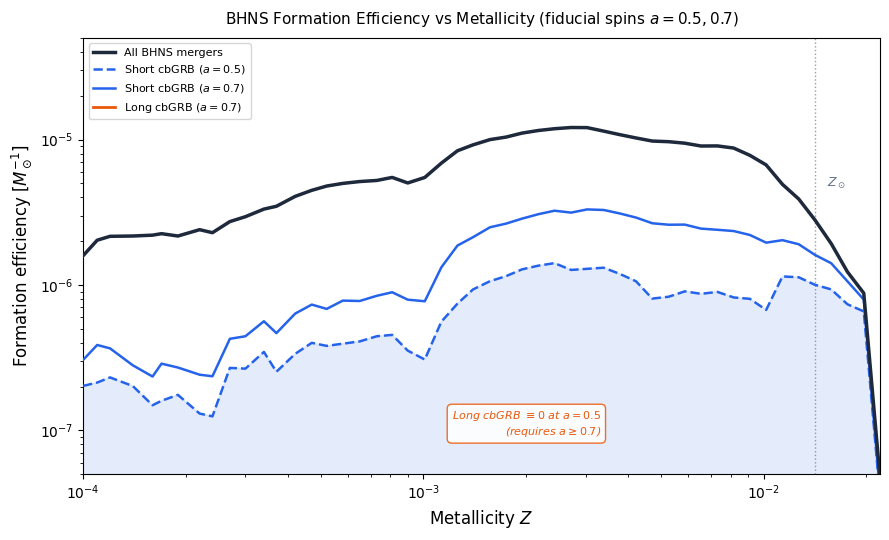

In [5]:
metallicityGrid = [0.0001, 0.00011, 0.00012, 0.00014, 0.00016, 0.00017,
                   0.00019, 0.00022, 0.00024, 0.00027, 0.0003,  0.00034,
                   0.00037, 0.00042, 0.00047, 0.00052, 0.00058, 0.00065,
                   0.00073, 0.00081, 0.0009,  0.00101, 0.00113, 0.00126,
                   0.0014,  0.00157, 0.00175, 0.00195, 0.00218, 0.00243,
                   0.00272, 0.00303, 0.00339, 0.00378, 0.00422, 0.00471,
                   0.00526, 0.00587, 0.00655, 0.00732, 0.00817, 0.00912,
                   0.01018, 0.01137, 0.01269, 0.01416, 0.01581, 0.01765,
                   0.01971, 0.022,   0.0244,  0.02705, 0.03]

meanMassEvolved = 77708655  # M_sun; see GRB_CosmicRate.ipynb Section 5 for derivation

Z_all   = metallicity[mask_merging]
w_all   = weights[mask_merging]
unique_Z = np.unique(metallicity)

no_fid, short_fid, long_fid, disk_fid = results[0.5]

eff_total = np.zeros(len(metallicityGrid))
eff_short_05 = np.zeros(len(metallicityGrid))
eff_long_05  = np.zeros(len(metallicityGrid))
eff_nogrb_05 = np.zeros(len(metallicityGrid))

for i, Z in enumerate(metallicityGrid):
    if Z in unique_Z:
        maskZ = (Z_all == Z)
        eff_total[i]    = np.sum(w_all[maskZ])                   / meanMassEvolved
        eff_short_05[i] = np.sum(w_all[maskZ & short_fid])       / meanMassEvolved
        eff_long_05[i]  = np.sum(w_all[maskZ & long_fid])        / meanMassEvolved
        eff_nogrb_05[i] = np.sum(w_all[maskZ & no_fid])          / meanMassEvolved

no_07, short_07, long_07, disk_07 = results[0.7]
eff_short_07 = np.zeros(len(metallicityGrid))
eff_long_07  = np.zeros(len(metallicityGrid))

for i, Z in enumerate(metallicityGrid):
    if Z in unique_Z:
        maskZ = (Z_all == Z)
        eff_short_07[i] = np.sum(w_all[maskZ & short_07]) / meanMassEvolved
        eff_long_07[i]  = np.sum(w_all[maskZ & long_07])  / meanMassEvolved

Z_solar = 0.0142
Z_max_plot = 0.022

fig, ax = plt.subplots(figsize=(9, 5.5))

mZ = np.array(metallicityGrid)

ax.fill_between(mZ, 0, eff_short_05,
                alpha=0.12, color='#2563EB', label=None, zorder=1)

ax.plot(mZ, eff_total, color='#1E293B', lw=2.5, label='All BHNS mergers', zorder=4)

ax.plot(mZ, eff_short_05, color='#2563EB', lw=1.8, ls='--',
        label=r'Short cbGRB ($a=0.5$)', zorder=3)

ax.plot(mZ, eff_short_07, color='#2563EB', lw=1.8, ls='-',
        label=r'Short cbGRB ($a=0.7$)', zorder=3)

ax.plot(mZ, eff_long_07, color='#EA580C', lw=2, ls='-',
        label=r'Long cbGRB ($a=0.7$)', zorder=3)

ax.axvline(Z_solar, color='#64748B', ls=':', lw=1, alpha=0.7, zorder=2)
ax.text(Z_solar * 1.08, 5e-6, r'$Z_\odot$', fontsize=9, color='#64748B', va='center')

ax.text(0.65, 0.15,
        r'Long cbGRB $\equiv 0$ at $a = 0.5$' + '\n'
        r'(requires $a \geq 0.7$)',
        transform=ax.transAxes, fontsize=8, color='#EA580C',
        ha='right', va='top', style='italic',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#EA580C', alpha=0.85))

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(mZ[0], Z_max_plot)
ax.set_ylim(5e-8, 5e-5)
ax.set_xlabel('Metallicity $Z$', fontsize=12)
ax.set_ylabel(r'Formation efficiency $[M_\odot^{-1}]$', fontsize=12)
ax.set_title('BHNS Formation Efficiency vs Metallicity (fiducial spins $a=0.5, 0.7$)',
             fontsize=11, pad=10)
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/Plots/bhns_formation_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

### Spin Sensitivity on Long cbGRB Efficiency

BH spin is the dominant factor controlling whether a BHNS merger produces a GRB at all. These per-metallicity efficiency curves feed into the spin-marginalized rate calculation in `GRB_CosmicRate.ipynb` (Section 14).

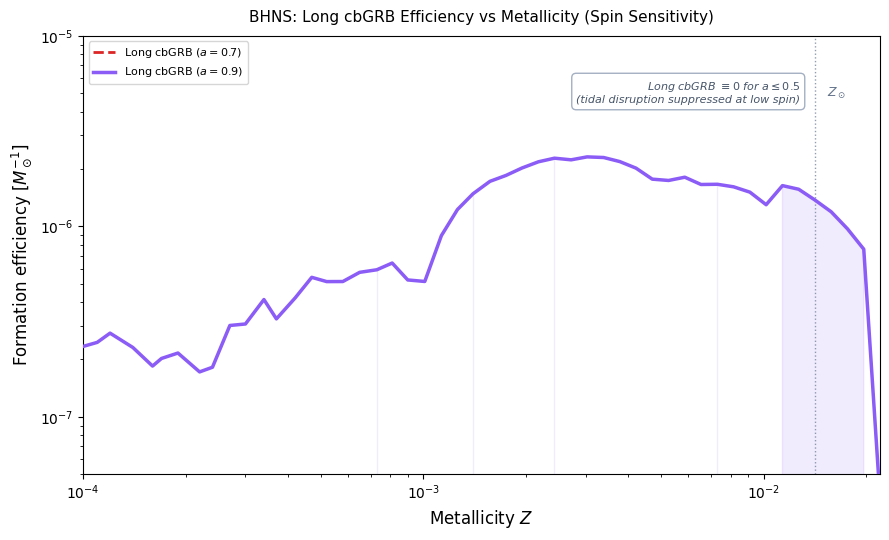

In [6]:
Z_solar = 0.0142
Z_max_plot = 0.022

fig, ax = plt.subplots(figsize=(9, 5.5))
mZ = np.array(metallicityGrid)

eff_07 = np.zeros(len(metallicityGrid))
eff_09 = np.zeros(len(metallicityGrid))
for a_val, eff_arr in [(0.7, eff_07), (0.9, eff_09)]:
    _, _, long_a, _ = results[a_val]
    for i, Z in enumerate(metallicityGrid):
        if Z in unique_Z:
            maskZ = (Z_all == Z)
            eff_arr[i] = np.sum(w_all[maskZ & long_a]) / meanMassEvolved

mask_fill = (eff_07 > 0) & (eff_09 > 0)
ax.fill_between(mZ, eff_07, eff_09, where=mask_fill,
                alpha=0.12, color='#8B5CF6', label=None, zorder=1)

ax.plot(mZ, eff_07, color='#DC2626', lw=2, ls='--',
        label=r'Long cbGRB ($a=0.7$)', zorder=3)
ax.plot(mZ, eff_09, color='#8B5CF6', lw=2.5, ls='-',
        label=r'Long cbGRB ($a=0.9$)', zorder=3)

ax.axvline(Z_solar, color='#64748B', ls=':', lw=1, alpha=0.7, zorder=2)
ax.text(Z_solar * 1.08, 5e-6, r'$Z_\odot$', fontsize=9,
        color='#64748B', va='center')

ax.text(0.9, 0.9,
        r'Long cbGRB $\equiv 0$ for $a \leq 0.5$' + '\n'
        r'(tidal disruption suppressed at low spin)',
        transform=ax.transAxes, fontsize=8, color='#475569',
        ha='right', va='top', style='italic',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#94A3B8', alpha=0.85))

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(mZ[0], Z_max_plot)
ax.set_ylim(5e-8, 1e-5)
ax.set_xlabel('Metallicity $Z$', fontsize=12)
ax.set_ylabel(r'Formation efficiency $[M_\odot^{-1}]$', fontsize=12)
ax.set_title('BHNS: Long cbGRB Efficiency vs Metallicity (Spin Sensitivity)',
             fontsize=11, pad=10)
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/Plots/bhns_spin_efficiency_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

### Remnant-to-Disk Fraction ($f_{\rm disk}$) Sensitivity

We adopt a constant $f_{\rm disk} = 0.4$ as a midrange estimate consistent with NR simulations showing $\sim 1/3$ to $\sim 2/3$ of remnant material settling into a disk (Foucart 2012, Sec. VI). This is a simplification of the standard dynamical-ejecta-subtraction approach (Coughlin et al. 2020; Kawaguchi et al. 2016). The $\sim 50\%$ spread in the NR-inferred disk fraction introduces comparable uncertainty in the effective $M_{\rm rem}$ threshold at the Long cbGRB boundary, partially degenerate with EOS and spin sensitivities.

Below we compare the fiducial $f_{\rm disk} = 0.4$ against $f_{\rm disk} = 1/3$ and $f_{\rm disk} = 1/2$ at spins $a = 0.7$ and $a = 0.9$ (the only spins that produce non-zero Long cbGRBs) for both Short and Long cbGRB efficiencies. This brackets the remnant-to-disk conversion uncertainty in the parameter space where it matters.

f_disk sensitivity at a = 0.7:
  Model                          No GRB       Short        Long
  $f_{\rm disk}=0.4$ (fiducial)   1,303,405     222,074          74
  $f_{\rm disk}=1/3$          1,320,704     204,849           0
  $f_{\rm disk}=1/2$          1,284,975     232,667       7,911

f_disk sensitivity at a = 0.9:
  Model                          No GRB       Short        Long
  $f_{\rm disk}=0.4$ (fiducial)     865,876     528,108     131,569
  $f_{\rm disk}=1/3$            884,921     587,093      53,539


  $f_{\rm disk}=1/2$            845,153     441,533     238,867



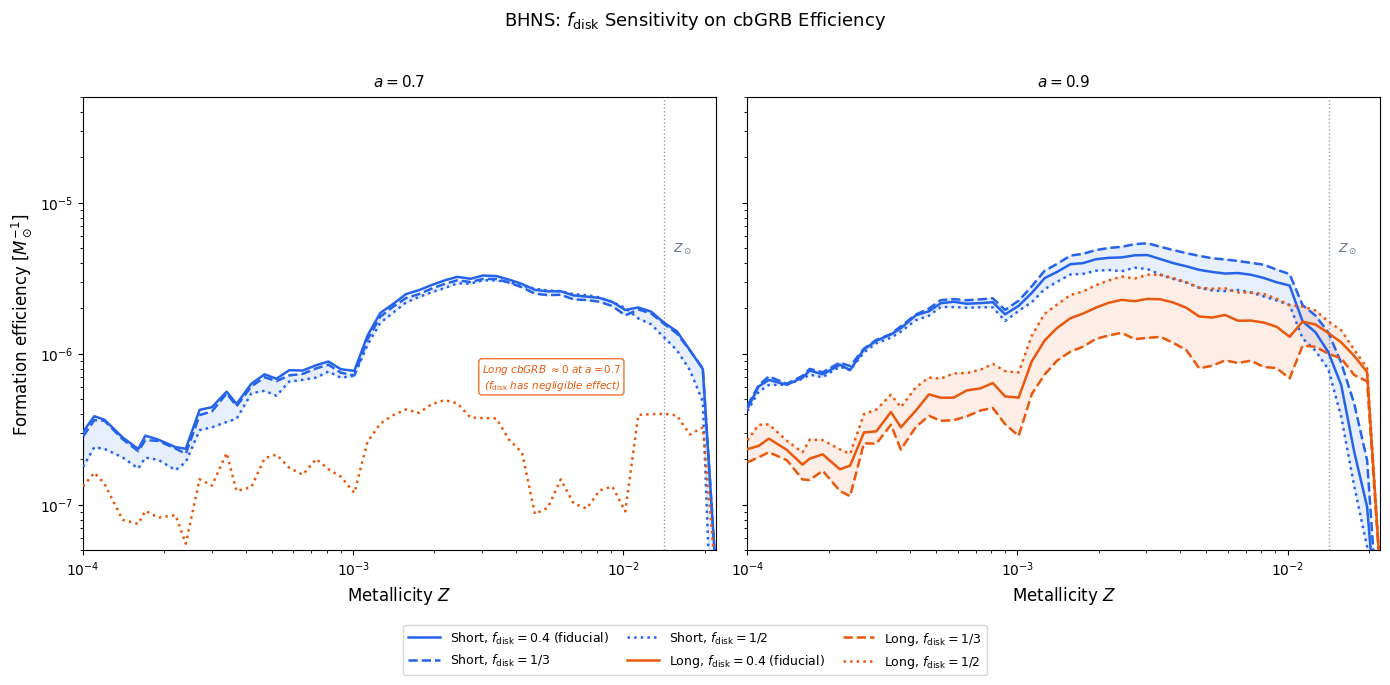

In [7]:
fdisk_models = {r'$f_{\rm disk}=0.4$ (fiducial)': F_DISK, r'$f_{\rm disk}=1/3$': 1/3, r'$f_{\rm disk}=1/2$': 1/2}
test_spins = [0.7, 0.9]

for a_spin in test_spins:
    print(f"f_disk sensitivity at a = {a_spin}:")
    print(f"  {'Model':<25s}  {'No GRB':>10s}  {'Short':>10s}  {'Long':>10s}")
    for label, fdc in fdisk_models.items():
        M_disk_fdc = foucart_disk_mass(BH, NS, a_BH=a_spin, f_disk=fdc)
        no_   = (M_disk_fdc < 0.01)
        short_ = (M_disk_fdc >= 0.01) & (M_disk_fdc < 0.1)
        long_  = (M_disk_fdc >= 0.1)
        print(f"  {label:<25s}  {no_.sum():>10,}  {short_.sum():>10,}  {long_.sum():>10,}")
    print()

Z_solar = 0.0142
Z_max_plot = 0.022
mZ = np.array(metallicityGrid)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for col, a_spin in enumerate(test_spins):
    ax = axes[col]

    eff_short = {}
    eff_long  = {}
    for label, fdc in fdisk_models.items():
        M_disk_fdc = foucart_disk_mass(BH, NS, a_BH=a_spin, f_disk=fdc)
        short_mask = (M_disk_fdc >= 0.01) & (M_disk_fdc < 0.1)
        long_mask  = (M_disk_fdc >= 0.1)

        es = np.zeros(len(metallicityGrid))
        el = np.zeros(len(metallicityGrid))
        for i, Z in enumerate(metallicityGrid):
            if Z in unique_Z:
                maskZ = (Z_all == Z)
                es[i] = np.sum(w_all[maskZ & short_mask]) / meanMassEvolved
                el[i] = np.sum(w_all[maskZ & long_mask])  / meanMassEvolved
        eff_short[label] = es
        eff_long[label]  = el

    labels_list = list(fdisk_models.keys())
    short_lo = eff_short[labels_list[1]]
    short_hi = eff_short[labels_list[2]]
    mask_s = (short_lo > 0) & (short_hi > 0)
    ax.fill_between(mZ, short_lo, short_hi, where=mask_s,
                    alpha=0.10, color='#2563EB', zorder=1)

    long_lo = eff_long[labels_list[1]]
    long_hi = eff_long[labels_list[2]]
    mask_l = (long_lo > 0) & (long_hi > 0)
    ax.fill_between(mZ, long_lo, long_hi, where=mask_l,
                    alpha=0.10, color='#EA580C', zorder=1)

    ls_map = {r'$f_{\rm disk}=0.4$ (fiducial)': '-', r'$f_{\rm disk}=1/3$': '--', r'$f_{\rm disk}=1/2$': ':'}
    for label in labels_list:
        ls = ls_map[label]
        ax.plot(mZ, eff_short[label], color='#2563EB', lw=1.8, ls=ls,
                label=f'Short, {label}', zorder=3)
    for label in labels_list:
        ls = ls_map[label]
        ax.plot(mZ, eff_long[label],  color='#EA580C', lw=1.8, ls=ls,
                label=f'Long, {label}', zorder=3)

    ax.axvline(Z_solar, color='#64748B', ls=':', lw=1, alpha=0.7, zorder=2)
    ax.text(Z_solar * 1.08, 5e-6, r'$Z_\odot$', fontsize=9,
            color='#64748B', va='center')

    if col == 0:
        ax.text(0.85, 0.35,
                r'Long cbGRB $\approx 0$ at $a = 0.7$' + '\n'
                r'($f_{\rm disk}$ has negligible effect)',
                transform=ax.transAxes, fontsize=7.5, color='#EA580C',
                ha='right', va='bottom', style='italic',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor='#EA580C', alpha=0.85))

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(mZ[0], Z_max_plot)
    ax.set_ylim(5e-8, 5e-5)
    ax.set_xlabel('Metallicity $Z$', fontsize=12)
    if col == 0:
        ax.set_ylabel(r'Formation efficiency $[M_\odot^{-1}]$', fontsize=12)
    ax.set_title(f'$a = {a_spin}$', fontsize=11, pad=8)

handles, lbl = axes[0].get_legend_handles_labels()
fig.legend(handles, lbl, fontsize=9, ncol=3,
           loc='lower center', bbox_to_anchor=(0.5, -0.10),
           columnspacing=1.5, handlelength=2.5)

fig.suptitle(r'BHNS: $f_{\rm disk}$ Sensitivity on cbGRB Efficiency',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/Plots/bhns_fdisk_sensitivity.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 6. EOS Sensitivity

A more compact NS (smaller `R_NS`, softer EOS) is harder to disrupt. To bracket the EOS uncertainty independent of the mass-dependent radius model, we override the default mass-dependent $R_{\rm NS}(M)$ with a **fixed** $R_{\rm NS}$ and vary it from 9 to 13 km.

Results are shown at $a = 0.5$, $0.7$, and $0.9$, spanning from negligible to strong tidal disruption. The $a = 0.9$ panel is the most informative, as this is the only spin regime producing a large Long cbGRB population (see Section 5).

**Note:** The default classification (Sections 3 to 5) uses a mass-dependent radius with $R_{1.4} = 12.0$ km. The fixed-radius sweep here provides a complementary sensitivity test that brackets the plausible range consistent with GW170817 and NICER constraints (Miller+ 2021, $R_{1.4} = 12.45^{+0.65}_{-0.65}$ km; Riley+ 2021, $R_{1.4} = 12.33^{+0.76}_{-0.81}$ km). The NICER-preferred band ($\sim$11.5 to 13 km) is shaded in each panel.

**Near-crossover at $a=0.9$, $R_{\rm NS}=13$ km:** The Short and Long cbGRB fractions converge ($\sim$38% vs $\sim$28%). At the stiffest plausible EOS with high spin, Long cbGRBs nearly equal Short cbGRBs indicating that the disk mass distribution piles up near the 0.1 $M_\odot$ classification boundary in this regime.

a=0.5, R_NS=9 km:  Long=0.0%  Short=0.0%  No GRB=100.0%
a=0.5, R_NS=10 km:  Long=0.0%  Short=0.3%  No GRB=99.7%
a=0.5, R_NS=11 km:  Long=0.0%  Short=1.3%  No GRB=98.7%
a=0.5, R_NS=12 km:  Long=0.0%  Short=3.6%  No GRB=96.4%
a=0.5, R_NS=13 km:  Long=0.0%  Short=7.9%  No GRB=92.1%
a=0.7, R_NS=9 km:  Long=0.0%  Short=0.7%  No GRB=99.3%
a=0.7, R_NS=10 km:  Long=0.0%  Short=2.7%  No GRB=97.3%


a=0.7, R_NS=11 km:  Long=0.0%  Short=7.4%  No GRB=92.6%
a=0.7, R_NS=12 km:  Long=0.0%  Short=15.3%  No GRB=84.7%
a=0.7, R_NS=13 km:  Long=0.7%  Short=23.9%  No GRB=75.4%
a=0.9, R_NS=9 km:  Long=0.0%  Short=11.6%  No GRB=88.4%
a=0.9, R_NS=10 km:  Long=0.3%  Short=22.9%  No GRB=76.8%
a=0.9, R_NS=11 km:  Long=2.4%  Short=34.1%  No GRB=63.5%


a=0.9, R_NS=12 km:  Long=9.0%  Short=43.4%  No GRB=47.5%
a=0.9, R_NS=13 km:  Long=20.3%  Short=48.4%  No GRB=31.3%


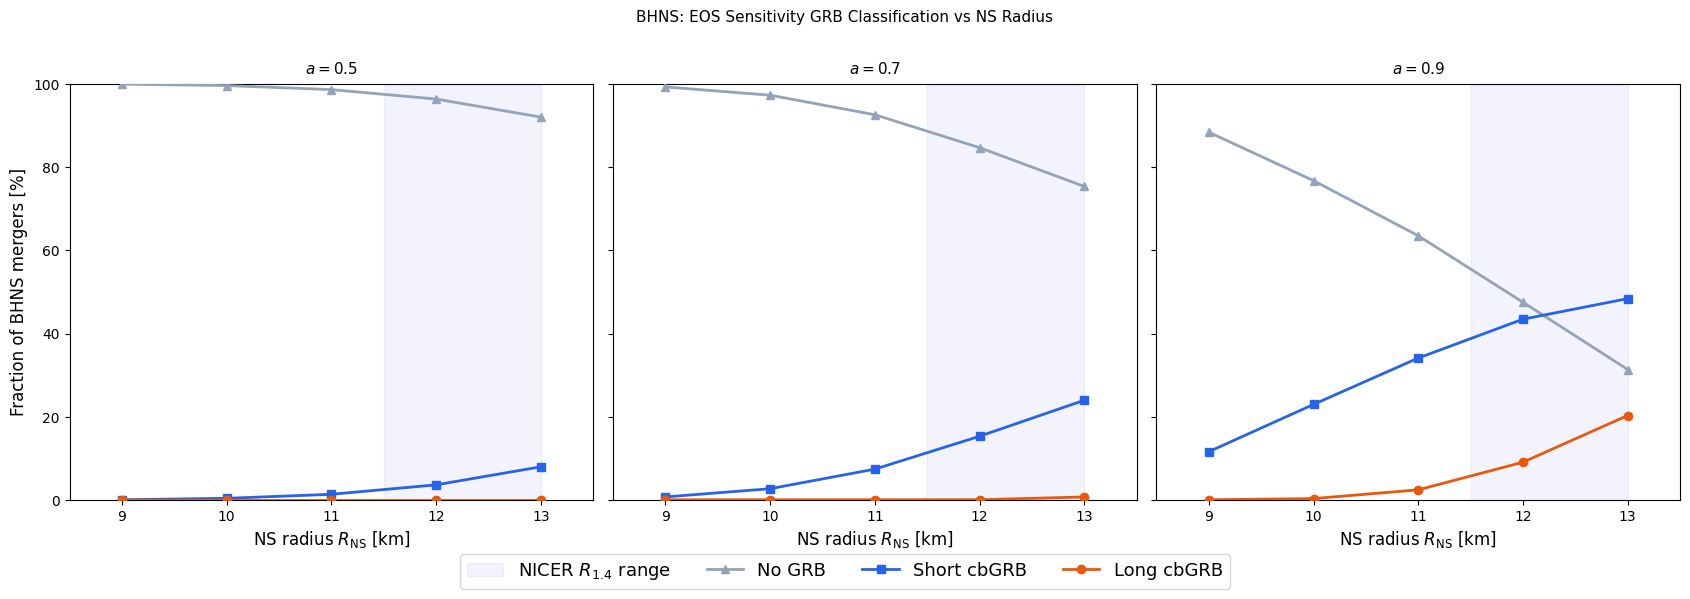

In [8]:
R_NS_range = [9, 10, 11, 12, 13]   # km
eos_spins  = [0.5, 0.7, 0.9]

results_RNS = {}
for a_spin in eos_spins:
    frac_long, frac_short, frac_nogrb = [], [], []
    for R in R_NS_range:
        M_disk    = foucart_disk_mass(BH, NS, a_BH=a_spin, R_NS_km=R)
        no_grb    = (M_disk < 0.01)
        long_grb  = (M_disk >= 0.1)
        short_grb = (M_disk >= 0.01) & (M_disk < 0.1)
        frac_long.append(100 * long_grb.mean())
        frac_short.append(100 * short_grb.mean())
        frac_nogrb.append(100 * no_grb.mean())
        print(f'a={a_spin}, R_NS={R} km:  '
              f'Long={100*long_grb.mean():.1f}%  '
              f'Short={100*short_grb.mean():.1f}%  '
              f'No GRB={100*no_grb.mean():.1f}%')
    results_RNS[a_spin] = dict(long=frac_long, short=frac_short, nogrb=frac_nogrb)

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), sharey=True)

for col, a_spin in enumerate(eos_spins):
    ax = axes[col]
    d  = results_RNS[a_spin]

    ax.axvspan(11.5, 13.0, alpha=0.08, color='#6366F1', zorder=0,
               label='NICER $R_{1.4}$ range' if col == 0 else None)

    ax.plot(R_NS_range, d['nogrb'], color='#94A3B8', lw=2, marker='^',
            label='No GRB', zorder=3)
    ax.plot(R_NS_range, d['short'], color='#2563EB', lw=2, marker='s',
            label='Short cbGRB', zorder=3)
    ax.plot(R_NS_range, d['long'],  color='#EA580C', lw=2, marker='o',
            label='Long cbGRB', zorder=3)

    ax.set_xlim(8.5, 13.5)
    ax.set_ylim(0, 100)
    ax.set_xticks(R_NS_range)
    ax.set_xlabel(r'NS radius $R_{\rm NS}$ [km]', fontsize=12)
    ax.set_title(f'$a = {a_spin}$', fontsize=11, pad=8)

    if col == 0:
        ax.set_ylabel('Fraction of BHNS mergers [%]', fontsize=12)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=13, ncol=4,
           loc='lower center', bbox_to_anchor=(0.5, -0.06),
           columnspacing=2.0, handlelength=2.0)

fig.suptitle('BHNS: EOS Sensitivity GRB Classification vs NS Radius',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/Plots/bhns_eos_sensitivity.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 7. Delay Time Distribution

Total delay time = stellar evolution time + coalescence time ($t_{\rm delay} = t_{\rm form} + t_{\rm c}$), shown for $a = 0.5$ and $a = 0.9$ to compare a spin with no Long cbGRBs against one where all three classes are populated.

The distribution is normalized to $dN/d\log t$ so that the expected $\sim t^{-1}$ power law (Neijssel+ 2019; Dominik+ 2012) appears as a roughly flat plateau. Stacked histograms show the composition of each delay-time bin by GRB class. Broekgaarden et al. (2021, their Figure 12) show that the delay time distribution shape for BHNS mergers is predominantly set by the metallicity-specific star formation history $\mathcal{S}(Z, z)$ rather than stellar evolution model variations, providing additional context for interpreting these distributions.

The visible dip at $\sim$50 to 200 Myr separates two populations: fast-merging systems with tight post-CE orbits ($t_{\rm delay} \lesssim 50$ Myr) and the bulk population with wider orbits requiring Gyr-scale gravitational-wave inspiral.

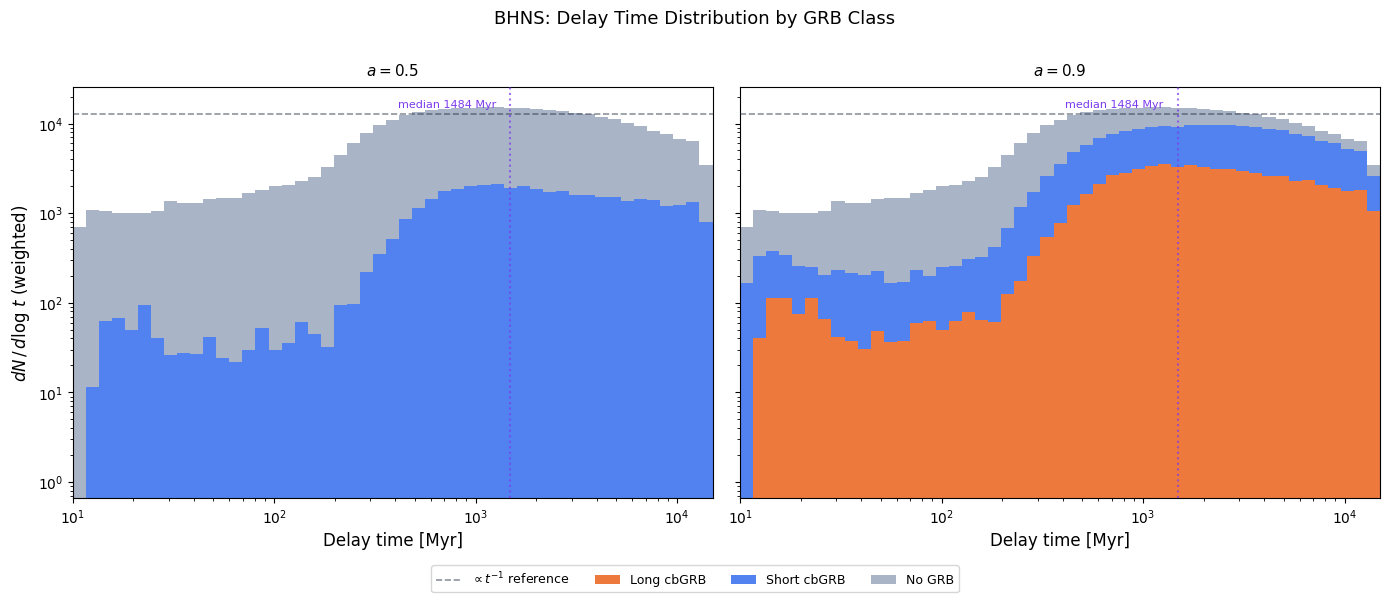

In [9]:
delay_BHNS_all = (tform + tc)[mask_merging]
w_m = weights[mask_merging]

bins = np.logspace(1, np.log10(1.5e4), 50)
dlogbins = np.diff(np.log10(bins))

delay_spins = [0.5, 0.9]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for col, a_spin in enumerate(delay_spins):
    ax = axes[col]
    no_a, short_a, long_a, _ = results[a_spin]

    cats   = [long_a, short_a, no_a]
    colors = ['#EA580C', '#2563EB', '#94A3B8']
    labels = ['Long cbGRB', 'Short cbGRB', 'No GRB']

    counts_all = []
    for mask in cats:
        c, _ = np.histogram(delay_BHNS_all[mask], bins=bins, weights=w_m[mask])
        counts_all.append(c / dlogbins)
    counts_arr = np.array(counts_all)

    bottom = np.zeros(len(bins) - 1)
    bar_w  = np.diff(bins)
    for i, (c, color, label) in enumerate(zip(counts_arr, colors, labels)):
        ax.bar(bins[:-1], c, width=bar_w, bottom=bottom, align='edge',
               color=color, alpha=0.80, label=label, zorder=2)
        bottom += c

    t_ref = np.logspace(1, np.log10(1.5e4), 100)
    ref_level = np.median(bottom[(bins[:-1] > 100) & (bins[:-1] < 5000)])
    ax.plot(t_ref, np.full_like(t_ref, ref_level), color='#1E293B',
            ls='--', lw=1.2, alpha=0.5, zorder=4,
            label=r'$\propto t^{-1}$ reference' if col == 0 else None)

    med_delay = np.median(delay_BHNS_all)
    ax.axvline(med_delay, color='#7C3AED', ls=':', lw=1.5, alpha=0.7, zorder=3)
    ax.text(med_delay * 0.85, 0.97, f'median {med_delay:.0f} Myr',
            fontsize=8, color='#7C3AED', ha='right', va='top',
            transform=ax.get_xaxis_transform())

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(10, 1.5e4)
    ax.set_xlabel('Delay time [Myr]', fontsize=12)
    if col == 0:
        ax.set_ylabel(r'$dN\,/\,d\log\,t$ (weighted)', fontsize=12)
    ax.set_title(f'$a = {a_spin}$', fontsize=11, pad=8)

handles, lbls = axes[0].get_legend_handles_labels()
fig.legend(handles, lbls, fontsize=9, ncol=4,
           loc='lower center', bbox_to_anchor=(0.5, -0.06),
           columnspacing=2.0, handlelength=2.0)

fig.suptitle('BHNS: Delay Time Distribution by GRB Class',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/Plots/bhns_delay_time_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()


## Export

Save formation efficiency arrays for use in the comparison notebook.

In [10]:
import numpy as np

np.save('/Users/josephrodriguez/research visualization/results/eff_BHNS.npy',
        np.array([eff_total, eff_short_05, eff_long_05, eff_nogrb_05,
                  eff_short_07, eff_long_07]))   # rows: total, short_05, long_05, nogrb_05, short_07, long_07
print("BHNS efficiencies saved.")

BHNS efficiencies saved.
